## Medidas de concentración

### Preprocesamiento de DataFrame

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import polars as pl


#Para poder utilizar archivos del proyecto
ROOT = Path.cwd().parent 
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.cleaning.preprocessing import pipeline_preprocesamiento

df = pipeline_preprocesamiento()

### Coeficiente de Gini

In [2]:
entidades_df = (
    df.filter(
        pl.col("sufrio_violencia_pareja").is_not_null() & 
        pl.col("factor_expansion").is_not_null()
    )
    .with_columns(
        (pl.col("sufrio_violencia_pareja") * pl.col("factor_expansion")).alias("casos_ponderados")
    )
    .group_by("nom_entidad")
    .agg(pl.col("casos_ponderados").sum().alias("total_casos_pond"))
    .sort("total_casos_pond")
)

n = entidades_df.height
entidades_df = entidades_df.with_columns(
    i=pl.int_range(1, n + 1, dtype=pl.Int64)
)

sum_x = entidades_df["total_casos_pond"].sum()
sum_ix = (entidades_df["i"] * entidades_df["total_casos_pond"]).sum()

gini = (2 * sum_ix - (n + 1) * sum_x) / (n * sum_x)

print(f"Coeficiente obtenido: {gini:.6f}")

Coeficiente obtenido: 0.417820


### Función de Preparación y Agregación Ponderada

In [3]:
def preparar_agregacion_ponderada(
    df: pl.DataFrame,
    target_col: str = "sufrio_violencia_pareja",
    peso_col: str = "factor_expansion",
    grupo_col: str = "nom_entidad"
) -> pl.DataFrame:
    """
    Filtra nulos, calcula la suma ponderada del indicador por grupo 
    y retorna el DataFrame ordenado de forma ascendente.
    """
    return (
        df.filter(pl.col(target_col).is_not_null() & pl.col(peso_col).is_not_null())
        .with_columns(
            (pl.col(target_col) * pl.col(peso_col)).alias("casos_ponderados")
        )
        .group_by(grupo_col)
        .agg(pl.col("casos_ponderados").sum().alias("total_casos_pond"))
        .sort("total_casos_pond")
    )


### Cálculo del Coeficiente de Gini

In [4]:
def calcular_coeficiente_gini(
    df_agrupado: pl.DataFrame, 
    valor_col: str = "total_casos_pond"
) -> float:
    """
    Calcula el Coeficiente de Gini para una serie ordenada de valores.
    
    Parámetros:
        df_agrupado: DataFrame que contiene la columna con el total de casos por unidad,
                     previamente ordenado de menor a mayor.
        valor_col: Nombre de la columna que contiene los valores acumulables.
    """
    n = df_agrupado.height
    if n == 0:
        return 0.0

    df_indexed = df_agrupado.with_columns(
        i=pl.int_range(1, n + 1, dtype=pl.Int64)
    )

    sum_x = df_indexed[valor_col].sum()
    if sum_x == 0:
        return 0.0

    sum_ix = (df_indexed["i"] * df_indexed[valor_col]).sum()
    gini = (2 * sum_ix - (n + 1) * sum_x) / (n * sum_x)
    
    return float(gini)

### Graficación de la Curva de Lorenz

In [5]:
def graficar_curva_lorenz(
    df_agrupado: pl.DataFrame,
    valor_col: str = "total_casos_pond",
    titulo: str = "Distribución de casos de violencia por entidad federativa",
    gini_val: float | None = None
) -> None:
    """
    Genera y muestra la Curva de Lorenz a partir del DataFrame agrupado y ordenado.
    
    Si no se pasa `gini_val`, lo calcula de forma automática usando la función interna.
    """
    n = df_agrupado.height
    if n == 0:
        print("El DataFrame está vacío, no se puede graficar.")
        return

    x = df_agrupado[valor_col].to_numpy()
    sum_x = np.sum(x)

    if sum_x == 0:
        print("La suma total de la variable es cero.")
        return

    # Si el valor de Gini no fue proporcionado, se calcula automáticamente
    if gini_val is None:
        gini_val = calcular_coeficiente_gini(df_agrupado, valor_col)

    # Cálculo de proporciones acumuladas para los ejes
    prop_unidades = np.linspace(0, 1, n + 1)
    prop_casos = np.insert(np.cumsum(x) / sum_x, 0, 0)

    # Construcción de la figura
    plt.figure(figsize=(8, 6))
    plt.plot(
        prop_unidades,
        prop_casos,
        color="#1f77b4",
        lw=2,
        label=f"Curva de Lorenz (Gini = {gini_val:.4f})"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        color="red",
        linestyle="--",
        lw=1.5,
        label="Distribución equitativa"
    )
    plt.fill_between(
        prop_unidades, prop_unidades, prop_casos, color="#1f77b4", alpha=0.15
    )

    plt.title(titulo, fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("Proporción acumulada de unidades (ej. entidades federativas)")
    plt.ylabel("Proporción acumulada del total de casos")
    plt.legend(loc="upper left")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

### Procesamiento Integrador de Atributos

In [6]:

def procesar_heterogeneidad_categorica(
    df: pl.DataFrame, 
    columnas: list[str], 
    peso_col: str | None = "factor_expansion"
) -> pl.DataFrame:
    """Procesa una lista de columnas categóricas e integra los resultados en un DataFrame."""
    resultados = []

    for col in columnas:
        cond = pl.col(col).is_not_null()
        if peso_col:
            cond = cond & pl.col(peso_col).is_not_null()

        df_filtrado = df.filter(cond)

        # Obtención de frecuencias relativas (p_i)
        if peso_col:
            frecuencias = df_filtrado.group_by(col).agg(
                peso_sum=pl.col(peso_col).sum()
            ).select(
                p=pl.col("peso_sum") / pl.col("peso_sum").sum()
            )
        else:
            frecuencias = df_filtrado.group_by(col).len().select(
                p=pl.col("len") / pl.col("len").sum()
            )

        k = frecuencias.height
        proporciones = frecuencias["p"]

        # Llamada a las funciones independientes
        gini_simpson, iqv = calcular_gini_simpson_iqv(proporciones)
        shannon_bits, shannon_norm = calcular_entropia_shannon(proporciones)

        resultados.append({
            "Atributo": col,
            "Categorías (K)": k,
            "Gini-Simpson": round(gini_simpson, 6),
            "Variación Cualitativa (IQV)": round(iqv, 6),
            "Entropía Shannon (bits)": round(shannon_bits, 6),
            "Entropía Normalizada": round(shannon_norm, 6)
        })

    return pl.DataFrame(resultados)

## Curva de Lorenz y coeficiente de Gini de casos de violencia

Coeficiente de Gini obtenido: 0.417820


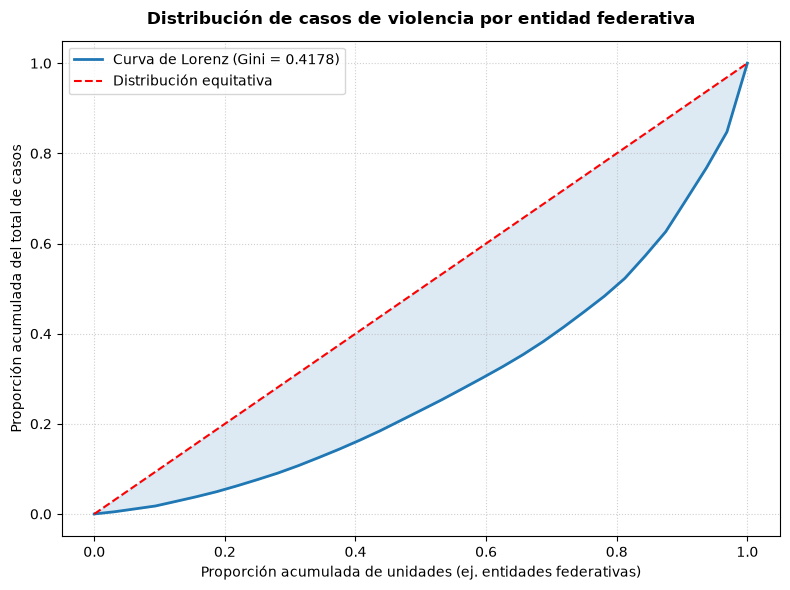

In [7]:
# Agregación y ordenamiento por entidad
entidades_df = preparar_agregacion_ponderada(
    df, 
    target_col="sufrio_violencia_pareja", 
    peso_col="factor_expansion", 
    grupo_col="nom_entidad"
)

# Coeficiente de Gini
gini_entidades = calcular_coeficiente_gini(entidades_df, valor_col="total_casos_pond")
print(f"Coeficiente de Gini obtenido: {gini_entidades:.6f}")

# Gráfica de curva
graficar_curva_lorenz(
    entidades_df, 
    valor_col="total_casos_pond", 
    titulo="Distribución de casos de violencia por entidad federativa",
    gini_val=gini_entidades
)